In [109]:
from models import get_embeddings,get_model
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [110]:
load_dotenv()

True

In [111]:
os.environ['LANGCHAIN_PROJECT'] = 'Tools project'

In [112]:
# Tools

search_tool = DuckDuckGoSearchRun(region = "us-en")

@tool
def calculator(first_num:float,second_num:float,operation:str) -> dict:
    """
    Perfom a basic arithmatic operation on two numbers.
    Supports operations: add,sub,nul,div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error":"Division by zero is nit possible"}
            result = first_num/second_num
        
        else:
            return {"error":f"Unsupported operation {operation}"}
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error":str(e)}

@tool
def get_stock_price(symbol:str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=A8PUQ61B5VJMD17O"
    r = requests.get(url)
    return r.json()


In [113]:
tools = [get_stock_price,search_tool,calculator]

In [114]:
llm = get_model()

In [115]:
llm_with_tools = llm.bind_tools(tools)

In [116]:
class ChatSate(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [134]:
def chat_node(ChatSate):
    """
    LLM that gives ans or call tools as per requirments
    """
    message = ChatSate["messages"]
    response = llm_with_tools.invoke(message)
    return {"messages":[response]}
    
tool_node = ToolNode(tools)

In [135]:
graph = StateGraph(ChatSate)

graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)


In [136]:
graph.add_edge(START,"chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")

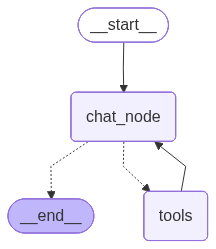

In [137]:
chatbot = graph.compile()
chatbot

In [138]:
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)

I'm ready to help. What would you like to do?


In [139]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

The result of 2*3 is 6.


In [133]:
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

{"Information": "We have detected your API key as A8PUQ61B5VJMD17O and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits."}


In [ ]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.1-8b-instant` in organization `org_01kmmqdnfkf4vt4mmamphk7ken` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 9814, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}